In [9]:
!pip install numpy pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [10]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
 
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

In [11]:
# Load the dataset

FILE_PATH = '../data/raw/house_price.csv'
 
df = pd.read_csv(FILE_PATH)
 
print("Dataset loaded successfully")
print(f"   File     : {FILE_PATH}")
print(f"   Rows     : {df.shape[0]:,}")
print(f"   Columns  : {df.shape[1]:,}")

Dataset loaded successfully
   File     : ../data/raw/house_price.csv
   Rows     : 1,458
   Columns  : 380


In [12]:
# Preview: first 5 rows

print("First 5 rows:")
df.head()

First 5 rows:


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,...,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Saleprice
0,1,18.145,13.833,7,3.992,2003,2003,19.433,144.118,0.000,29.991,422.489,5.939,1025.652,0.000,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,208501.000
1,2,20.674,14.118,6,6.000,1976,1976,54.598,181.719,0.000,44.135,593.888,6.235,665.142,0.000,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,181501.000
2,3,18.668,14.477,7,3.992,2001,2002,17.769,110.441,0.000,56.897,450.080,5.994,1040.521,0.000,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,223501.000
3,4,17.250,14.106,7,3.992,1915,1970,54.598,61.795,0.000,64.809,378.855,6.028,904.477,0.000,...,0,0,0,0,0,0,0,1,1,0,0,0,0,0,140001.000
4,5,21.314,15.022,8,3.992,2000,2000,25.404,136.625,0.000,61.166,545.310,6.161,1273.025,0.000,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,250001.000


In [13]:
# Preview: last 5 rows

print("Last 5 rows:")
df.tail()

Last 5 rows:


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,...,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Saleprice
1453,1454,17.611,13.689,6,3.992,1999,2000,54.598,665.142,0.000,90.760,464.213,6.021,828.069,0.000,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,175001.000
1454,1455,21.472,14.839,6,4.680,1978,1988,15.343,156.123,8.046,68.244,707.987,6.607,665.142,0.000,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,210001.000
1455,1456,18.320,13.984,7,6.638,1941,2006,54.598,73.494,0.000,86.408,548.233,6.189,1396.663,0.000,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,266501.000
1456,1457,18.668,14.145,5,4.680,1950,1996,54.598,21.007,13.088,0.000,517.217,6.115,665.142,0.000,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,142126.000
1457,1458,19.854,14.195,5,4.680,1965,1965,54.598,161.707,9.457,28.249,591.411,6.231,665.142,0.000,...,0,0,0,0,0,0,0,1,0,0,0,0,1,0,147501.000


In [14]:
# Shape & dimensions

print("=" * 45)
print("SHAPE & DIMENSIONS")
print("=" * 45)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]:,}")
print(f"  Cells   : {df.shape[0] * df.shape[1]:,}")


SHAPE & DIMENSIONS
  Rows    : 1,458
  Columns : 380
  Cells   : 554,040


In [15]:
# Column names (all 380)
print(f"Total columns: {len(df.columns)}\n")
 
# Group columns by type for readability
raw_num     = [c for c in df.columns if df[c].dtype in ['int64','float64']
               and not any(c.startswith(p) for p in
               ['MSSubClass_','MSZoning_','Alley_','LotShape_','LandContour_',
                'LotConfig_','LandSlope_','Neighborhood_','Condition1_',
                'Condition2_','BldgType_','HouseStyle_','RoofStyle_',
                'RoofMatl_','Exterior','MasVnrType','ExterQual','ExterCond',
                'Foundation_','BsmtQual','BsmtCond','BsmtExposure','BsmtFin',
                'Heating','CentralAir','Electrical','KitchenQual','Functional',
                'FireplaceQu','GarageType','GarageFinish','GarageQual',
                'GarageCond','PavedDrive','Fence_','MiscFeature','MoSold',
                'YrSold_','SaleType_','SaleCondition_',
                'Has','has','is_','Total_','YearsSince','YrBlt'])
               and not c.endswith('_log') and not c.endswith('_sq')
               and not c.endswith('_log_sq')]
 
engineered  = [c for c in df.columns if any(c.startswith(p) for p in
               ['Total_','YearsSince','YrBlt']) or
               any(c.startswith(p) for p in ['Has','has','is_'])]
 
log_cols    = [c for c in df.columns if c.endswith('_log') or c.endswith('_log_sq') or c.endswith('_sq')]
 
ohe_cols    = [c for c in df.columns if c not in raw_num + engineered + log_cols + ['Id','Saleprice']]
 
print(f"  Raw numeric features     : {len(raw_num)}")
print(f"  Engineered features      : {len(engineered)}")
print(f"  Log / polynomial cols    : {len(log_cols)}")
print(f"  One-hot encoded cols     : {len(ohe_cols)}")
print(f"  Id + target (Saleprice)  : 2")


Total columns: 380

  Raw numeric features     : 34
  Engineered features      : 16
  Log / polynomial cols    : 38
  One-hot encoded cols     : 292
  Id + target (Saleprice)  : 2


In [16]:
# Data types

print("=" * 45)
print("DATA TYPES")
print("=" * 45)
print(df.dtypes.value_counts())
print()
print("Breakdown:")
print(f"  int64   : {(df.dtypes == 'int64').sum()} columns")
print(f"  float64 : {(df.dtypes == 'float64').sum()} columns")
print(f"  object  : {(df.dtypes == 'object').sum()} columns")


DATA TYPES
int64      309
float64     71
Name: count, dtype: int64

Breakdown:
  int64   : 309 columns
  float64 : 71 columns
  object  : 0 columns


In [17]:
# Memory usage

mem_bytes  = df.memory_usage(deep=True).sum()
mem_mb     = mem_bytes / (1024 ** 2)
 
print("=" * 45)
print("MEMORY USAGE")
print("=" * 45)
print(f"  Total memory : {mem_mb:.2f} MB  ({mem_bytes:,} bytes)")
print(f"  Per row      : {mem_bytes / len(df):,.0f} bytes")
print(f"  Per column   : {mem_bytes / len(df.columns):,.0f} bytes avg")
print()
print("Top 10 columns by memory:")
col_mem = df.memory_usage(deep=True).sort_values(ascending=False)[1:11]
for col, mem in col_mem.items():
    print(f"  {col:<35} {mem/1024:>8.1f} KB")


MEMORY USAGE
  Total memory : 4.23 MB  (4,432,452 bytes)
  Per row      : 3,040 bytes
  Per column   : 11,664 bytes avg

Top 10 columns by memory:
  BsmtQual_Gd                             11.4 KB
  BsmtExposure_Gd                         11.4 KB
  BsmtExposure_Av                         11.4 KB
  BsmtCond_TA                             11.4 KB
  BsmtCond_Po                             11.4 KB
  BsmtCond_None                           11.4 KB
  BsmtCond_Gd                             11.4 KB
  BsmtCond_Fa                             11.4 KB
  BsmtQual_TA                             11.4 KB
  BsmtQual_None                           11.4 KB


In [18]:
# Target variable: Saleprice

print("=" * 45)
print("TARGET VARIABLE: Saleprice")
print("=" * 45)
sp = df['Saleprice']
print(f"  Count   : {sp.count():,}")
print(f"  Min     : ${sp.min():>12,.0f}")
print(f"  Q1      : ${sp.quantile(0.25):>12,.0f}")
print(f"  Median  : ${sp.median():>12,.0f}")
print(f"  Mean    : ${sp.mean():>12,.0f}")
print(f"  Q3      : ${sp.quantile(0.75):>12,.0f}")
print(f"  Max     : ${sp.max():>12,.0f}")
print(f"  Std Dev : ${sp.std():>12,.0f}")
print(f"  Skewness: {sp.skew():>12.3f}  (>1 = right-skewed → log transform needed)")
print(f"  Nulls   : {sp.isnull().sum()}")

TARGET VARIABLE: Saleprice
  Count   : 1,458
  Min     : $      34,901
  Q1      : $     129,926
  Median  : $     163,001
  Mean    : $     180,934
  Q3      : $     214,001
  Max     : $     755,001
  Std Dev : $      79,495
  Skewness:        1.881  (>1 = right-skewed → log transform needed)
  Nulls   : 0


In [19]:
# Missing values audit

print("=" * 45)
print("MISSING VALUES")
print("=" * 45)
total_missing = df.isnull().sum().sum()
print(f"  Total missing cells : {total_missing}")
 
if total_missing == 0:
    print("No missing values — dataset is fully complete")
else:
    missing_cols = df.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0].sort_values(ascending=False)
    print(f"  Columns with nulls  : {len(missing_cols)}")
    print()
    print(missing_cols.to_frame('missing_count').assign(
        pct=lambda x: (x['missing_count'] / len(df) * 100).round(2)
    ))


MISSING VALUES
  Total missing cells : 0
No missing values — dataset is fully complete


In [20]:
# Duplicate check

print("=" * 45)
print("DUPLICATE CHECK")
print("=" * 45)
dup_rows = df.duplicated().sum()
dup_ids  = df['Id'].duplicated().sum()
print(f"  Duplicate rows     : {dup_rows}")
print(f"  Duplicate Id values: {dup_ids}")
 
if dup_rows == 0 and dup_ids == 0:
    print("No duplicates found — all rows are unique")


DUPLICATE CHECK
  Duplicate rows     : 0
  Duplicate Id values: 0
No duplicates found — all rows are unique


In [21]:
# Unique value counts per column (sample)

print("=" * 45)
print("UNIQUE VALUE COUNTS (key columns)")
print("=" * 45)
 
key_cols = ['OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
            'GarageCars', 'BedroomAbvGr', 'TotRmsAbvGrd', 'FullBath']
key_cols = [c for c in key_cols if c in df.columns]
 
for col in key_cols:
    vals = sorted(df[col].unique())
    print(f"  {col:<20} {df[col].nunique():>3} unique values  |  range: {min(vals)} → {max(vals)}")
 
print(f"\n  Neighbourhoods (one-hot): {len([c for c in df.columns if c.startswith('Neighborhood_')])}")
print(f"  Sale years (one-hot)    : {len([c for c in df.columns if c.startswith('YrSold_')])}")
print(f"  Sale months (one-hot)   : {len([c for c in df.columns if c.startswith('MoSold_')])}")


UNIQUE VALUE COUNTS (key columns)
  OverallQual           10 unique values  |  range: 1 → 10
  OverallCond            9 unique values  |  range: 0.9264013793334038 → 6.637669447090252
  YearBuilt            112 unique values  |  range: 1872 → 2010
  YearRemodAdd          61 unique values  |  range: 1950 → 2010
  GarageCars             5 unique values  |  range: 0.0 → 4.0
  BedroomAbvGr           8 unique values  |  range: 0 → 8
  TotRmsAbvGrd          12 unique values  |  range: 1.114641810176651 → 2.8068430754456646
  FullBath               4 unique values  |  range: 0 → 3

  Neighbourhoods (one-hot): 25
  Sale years (one-hot)    : 5
  Sale months (one-hot)   : 12


In [22]:
# Descriptive statistics (numeric columns)

print("Descriptive statistics — key raw numeric columns:")
key_num = ['LotArea','OverallQual','OverallCond','YearBuilt','YearRemodAdd',
           'GrLivArea','TotalBsmtSF','GarageArea','GarageCars',
           'TotalSF','Total_Home_Quality','Total_Bathrooms','Saleprice']
key_num = [c for c in key_num if c in df.columns]
df[key_num].describe().round(2)


Descriptive statistics — key raw numeric columns:


,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,GrLivArea,TotalBsmtSF,GarageArea,GarageCars,TotalSF,Total_Home_Quality,Total_Bathrooms,Saleprice
count,1458.000,1458.000,1458.000,1458.000,1458.000,1458.000,1458.000,1458.000,1458.000,1458.000,1458.000,1458.000,1458.000
mean,14.010,6.090,4.380,1971.220,1984.830,8.130,511.830,494.460,1.770,922.920,10.470,2.210,180933.920
std,1.150,1.380,0.760,30.190,20.640,0.410,158.550,180.050,0.750,521.190,1.510,0.790,79495.060
min,10.000,1.000,0.930,1872.000,1950.000,6.360,66.750,160.000,0.000,5.200,1.930,0.990,34901.000
25%,13.580,5.000,3.990,1954.000,1967.000,7.840,403.430,389.250,1.000,521.220,9.680,1.890,129926.000
50%,14.090,6.000,3.990,1972.500,1994.000,8.160,480.410,479.500,2.000,746.120,10.680,2.000,163001.000
75%,14.550,7.000,4.680,2000.000,2004.000,8.400,608.210,576.000,2.000,1294.670,11.350,2.530,214001.000
max,22.150,10.000,6.640,2010.000,2010.000,9.580,1344.980,1390.000,4.000,3598.810,16.640,5.960,755001.000


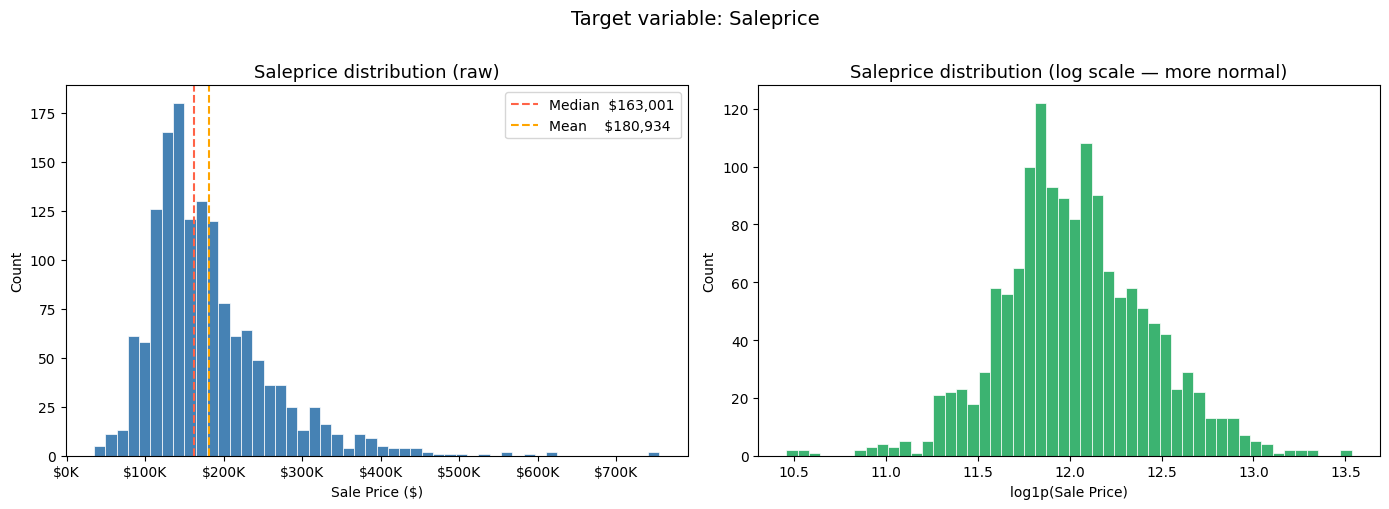

Saved → ../tableau/screenshots/01_saleprice_distribution.png


In [23]:
# Saleprice distribution chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Raw
axes[0].hist(df['Saleprice'], bins=50, color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Saleprice'].median(), color='tomato',
                linestyle='--', linewidth=1.5,
                label=f"Median  ${df['Saleprice'].median():,.0f}")
axes[0].axvline(df['Saleprice'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Mean    ${df['Saleprice'].mean():,.0f}")
axes[0].set_title('Saleprice distribution (raw)', fontsize=13)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend()
 
# Log-transformed
axes[1].hist(np.log1p(df['Saleprice']), bins=50,
             color='mediumseagreen', edgecolor='white', linewidth=0.5)
axes[1].set_title('Saleprice distribution (log scale — more normal)', fontsize=13)
axes[1].set_xlabel('log1p(Sale Price)')
axes[1].set_ylabel('Count')
 
plt.suptitle('Target variable: Saleprice', fontsize=14, y=1.01)
plt.tight_layout()
 
os.makedirs('../tableau/screenshots', exist_ok=True)
plt.savefig('../tableau/screenshots/01_saleprice_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../tableau/screenshots/01_saleprice_distribution.png")


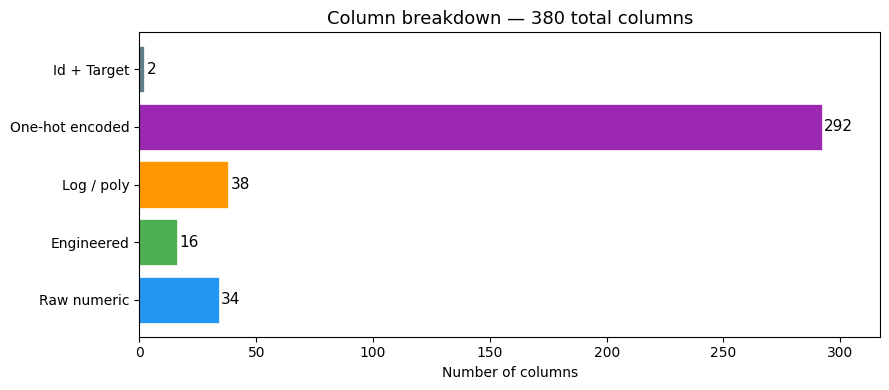

Saved → ../tableau/screenshots/01_column_breakdown.png


In [24]:
# Column category breakdown chart

categories = {
    'Raw numeric'     : len(raw_num),
    'Engineered'      : len(engineered),
    'Log / poly'      : len(log_cols),
    'One-hot encoded' : len(ohe_cols),
    'Id + Target'     : 2,
}
 
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#607D8B']
bars = ax.barh(list(categories.keys()), list(categories.values()),
               color=colors, edgecolor='white', linewidth=0.5)
 
for bar, val in zip(bars, categories.values()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11)
 
ax.set_xlabel('Number of columns')
ax.set_title(f'Column breakdown — {df.shape[1]} total columns', fontsize=13)
ax.set_xlim(0, max(categories.values()) + 25)
 
plt.tight_layout()
plt.savefig('../tableau/screenshots/01_column_breakdown.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../tableau/screenshots/01_column_breakdown.png")


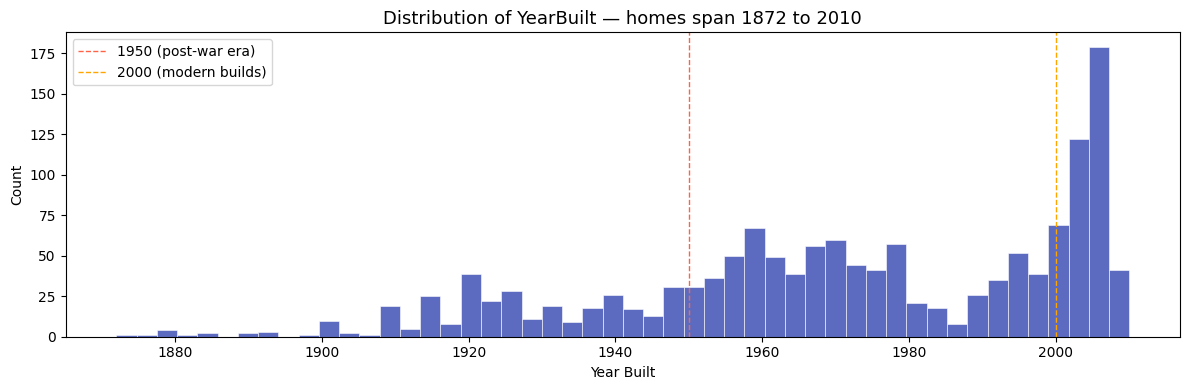

Saved → ../tableau/screenshots/01_yearbuilt_distribution.png


In [25]:
# Year built distribution

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df['YearBuilt'], bins=50, color='#5C6BC0',
        edgecolor='white', linewidth=0.4)
ax.axvline(1950, color='tomato', linestyle='--', linewidth=1,
           label='1950 (post-war era)')
ax.axvline(2000, color='orange', linestyle='--', linewidth=1,
           label='2000 (modern builds)')
ax.set_title('Distribution of YearBuilt — homes span 1872 to 2010', fontsize=13)
ax.set_xlabel('Year Built')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../tableau/screenshots/01_yearbuilt_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../tableau/screenshots/01_yearbuilt_distribution.png")
 


In [26]:
# Extraction summary (for report Section 5)

print("=" * 55)
print("EXTRACTION SUMMARY  —  Section 5: Data Description")
print("=" * 55)
print(f"""
Dataset       : house_price.csv
Source        : Kaggle — Ames Housing Dataset (feature-engineered)
Rows          : {df.shape[0]:,}
Columns       : {df.shape[1]:,}
Memory usage  : {mem_mb:.2f} MB
 
Target variable: Saleprice
  Min    : ${df['Saleprice'].min():>10,.0f}
  Median : ${df['Saleprice'].median():>10,.0f}
  Mean   : ${df['Saleprice'].mean():>10,.0f}
  Max    : ${df['Saleprice'].max():>10,.0f}
  Skew   : {df['Saleprice'].skew():.3f} (right-skewed)
 
Time period   : YrSold 2006 – 2010
Geographies   : Ames, Iowa — 25 neighbourhoods (one-hot encoded)
Missing values: {df.isnull().sum().sum()}
Duplicates    : {df.duplicated().sum()}
 
Column breakdown:
  Raw numeric features  : {len(raw_num)}
  Engineered composites : {len(engineered)}
  Log / polynomial cols : {len(log_cols)}
  One-hot encoded cols  : {len(ohe_cols)}
  Id + Saleprice        : 2
 
Key engineered features:
  TotalSF              = 1stFlrSF + 2ndFlrSF + TotalBsmtSF
  Total_Home_Quality   = OverallQual + OverallCond
  Total_Bathrooms      = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
  YearsSinceRemodel    = YrSold - YearRemodAdd
  haspool, hasgarage, hasbsmt, hasfireplace (binary flags)
 
Saved charts → ../tableau/screenshots/
  01_saleprice_distribution.png
  01_column_breakdown.png
  01_yearbuilt_distribution.png
 
Extraction complete. Next step → notebooks/02_cleaning.ipynb
""")


EXTRACTION SUMMARY  —  Section 5: Data Description

Dataset       : house_price.csv
Source        : Kaggle — Ames Housing Dataset (feature-engineered)
Rows          : 1,458
Columns       : 380
Memory usage  : 4.23 MB

Target variable: Saleprice
  Min    : $    34,901
  Median : $   163,001
  Mean   : $   180,934
  Max    : $   755,001
  Skew   : 1.881 (right-skewed)

Time period   : YrSold 2006 – 2010
Geographies   : Ames, Iowa — 25 neighbourhoods (one-hot encoded)
Missing values: 0
Duplicates    : 0

Column breakdown:
  Raw numeric features  : 34
  Engineered composites : 16
  Log / polynomial cols : 38
  One-hot encoded cols  : 292
  Id + Saleprice        : 2

Key engineered features:
  TotalSF              = 1stFlrSF + 2ndFlrSF + TotalBsmtSF
  Total_Home_Quality   = OverallQual + OverallCond
  Total_Bathrooms      = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
  YearsSinceRemodel    = YrSold - YearRemodAdd
  haspool, hasgarage, hasbsmt, hasfireplace (binary flags)

Save